# 📐 วิเคราะห์การยกแบบทีละเฟรม: ตำแหน่งมือ · มุมบิดตัว · ตารางน้ำหนักปลอดภัย

**รายวิชา CP413705 การฝึกปฏิบัติงานปัญญาประดิษฐ์ 3 (AI Workshop III)** · วิทยาลัยการคอมพิวเตอร์ มหาวิทยาลัยขอนแก่น

Notebook นี้สร้าง **โมเดลเชิงเรขาคณิต** ที่คำนวณจาก keypoint ของร่างกายโดยตรง (ไม่ต้องเทรน) เพื่อตอบคำถามในทุกเฟรมว่า

1. มือของผู้ยกอยู่ **สูงเท่าไร (V)** และ **ห่างจากข้อเท้าเท่าไร (H)** — นิยามแบบ **NIOSH Lifting Equation**
2. ลำตัว **หันทำมุมกับกล้อง** เท่าไร และ **บิดตัว** เท่าไร
3. ณ ตำแหน่งมือนั้น **น้ำหนักสูงสุดที่ยอมรับได้** คือกี่กิโลกรัม — แสดงเป็นตารางบนวิดีโอ

## 🗺️ ภาพรวม (ทำซ้ำทุกเฟรม)

```
 วิดีโอ ─► ① อ่านเฟรม ─► ② สกัด keypoint ─► ③ ลดการสั่น ─► ④ วาด keypoint
                                                   │
      ┌────────────────────────────────────────────┘
      ▼
 ⑤ สเกล ซม./พิกเซล + พิกัด 3 มิติ ─► ⑥ มุมหันเทียบกล้อง ─► ⑦ มุมบิดตัว
      │
      ▼
 ⑧ ตาราง 3×4 (Perspective Transform) + น้ำหนัก ณ ตำแหน่งมือ ─► ⑨ เขียนวิดีโอ
```

## 📋 ตารางเกณฑ์น้ำหนักสูงสุดที่ยอมรับได้ (Max Acceptable Weight Limits)

| ระดับความสูงของมือ | Near (0″–7″) | Mild (7″–12″) | Extended (> 12″) |
|---|---|---|---|
| Above Shoulder | 29 kg | 18 kg | 14 kg |
| Waist to Shoulder | 32 kg | 23 kg | 18 kg |
| Knee to Waist | **41 kg (สูงสุด)** | 25 kg | 18 kg |
| Below Knee | 31 kg | 23 kg | 16 kg |

1 นิ้ว = 2.54 ซม. → **7″ = 17.8 ซม.** และ **12″ = 30.5 ซม.**

## 📁 สิ่งที่ต้องเตรียม

| รายการ | หมายเหตุ |
|---|---|
| วิดีโอการยก `.mp4` | ถ่ายด้วยกล้องตั้งนิ่ง ผู้ยก **ยืนตรงนิ่ง 2 วินาทีแรก** (ตามโปรโตคอล Workshop07) |
| ส่วนสูงจริงของผู้ยก (ซม.) | กรอกในขั้นที่ 0.2 |
| `pose_landmarker_lite.task` | ดาวน์โหลดให้อัตโนมัติ |

> 💡 **วิธีใช้ใน Colab:** กด `Runtime ▸ Run all` หรือรันทีละเซลล์ด้วย `Shift+Enter` จากบนลงล่าง (ไม่ต้องใช้ GPU)

---
## ขั้นที่ 0 · เตรียมสภาพแวดล้อม

### 0.1 ติดตั้งและนำเข้าไลบรารี

In [1]:
import subprocess, sys

try:
    import mediapipe
except ImportError:
    print("กำลังติดตั้ง mediapipe ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "mediapipe"])

import math, re, time, shutil, base64, urllib.request, warnings
from pathlib import Path
from collections import deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from IPython.display import HTML, display

warnings.filterwarnings("ignore", category=RuntimeWarning)   # ไม่ต้องแสดงคำเตือนเมื่อเฉลี่ยค่าที่เป็น NaN ทั้งหมด
print("OpenCV", cv2.__version__, "| MediaPipe", mp.__version__)

กำลังติดตั้ง mediapipe ...
OpenCV 5.0.0 | MediaPipe 1.0.1


### 0.2 ตั้งค่า 👉 MODIFY
- **บน Colab** ไฟล์อยู่ที่ `/content/lift_demo` (ดูได้ที่แถบ 📁 *Files* ด้านซ้าย) — ไฟล์หายเมื่อปิด runtime
- **บนเครื่องตัวเอง** ใช้โฟลเดอร์ที่ notebook วางอยู่

In [2]:
IN_COLAB = "google.colab" in sys.modules
BASE = Path("/content/lift_demo") if IN_COLAB else Path.cwd()   # 👉 MODIFY — โฟลเดอร์ทำงาน
BASE.mkdir(parents=True, exist_ok=True)

VIDEO_NAME        = "G04_S03_AS-WS_RF_T1_PF_05.mp4"   # 👉 MODIFY — ชื่อไฟล์วิดีโอ
SUBJECT_HEIGHT_CM = 160.0                             # 👉 MODIFY — ส่วนสูงจริงของผู้ยก (ซม.)
MAX_FRAMES        = None                              # 👉 MODIFY — เช่น 150 เพื่อทดลองเร็ว ๆ · None = ทั้งคลิป

VIDEO_PATH      = BASE / VIDEO_NAME
POSE_MODEL_PATH = BASE / "models" / "pose_landmarker_lite.task"
OUTPUT_DIR      = BASE / "weight_limit_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 0.3 เตรียมไฟล์
ถ้ายังไม่มีวิดีโอและรันบน Colab จะขึ้นปุ่ม **Choose Files** ให้อัปโหลด · โมเดล MediaPipe ดาวน์โหลดให้อัตโนมัติ

In [3]:
POSE_MODEL_URL = ("https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
                  "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task")

if not POSE_MODEL_PATH.is_file():
    POSE_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("กำลังดาวน์โหลดโมเดล MediaPipe ...")
    urllib.request.urlretrieve(POSE_MODEL_URL, POSE_MODEL_PATH)

if IN_COLAB and not VIDEO_PATH.is_file():
    from google.colab import files
    print(f"📤 เลือกไฟล์วิดีโอ ({VIDEO_NAME})")
    for name, data in files.upload().items():
        (BASE / name).write_bytes(data)

print("วิดีโอ   :", "✅" if VIDEO_PATH.is_file() else "❌ ไม่พบ", VIDEO_PATH)
print("MediaPipe:", "✅" if POSE_MODEL_PATH.is_file() else "❌ ไม่พบ", POSE_MODEL_PATH)

กำลังดาวน์โหลดโมเดล MediaPipe ...
📤 เลือกไฟล์วิดีโอ (G04_S03_AS-WS_RF_T1_PF_05.mp4)


Saving G04_S03_AS-WS_RF_T1_PF_05.mp4 to G04_S03_AS-WS_RF_T1_PF_05.mp4
วิดีโอ   : ✅ /content/lift_demo/G04_S03_AS-WS_RF_T1_PF_05.mp4
MediaPipe: ✅ /content/lift_demo/models/pose_landmarker_lite.task


---
## ขั้นที่ ① · อ่านและโหลดเฟรมภาพจากไฟล์วิดีโอ

วิดีโอคือ **ภาพนิ่ง (เฟรม) หลายภาพเรียงต่อกัน** — ชุดข้อมูลของเราบันทึกที่ 30 เฟรมต่อวินาที
- `cv2.VideoCapture(path)` เปิดวิดีโอ แล้ว `cap.read()` คืน `(ok, frame)` ทีละเฟรม (`ok = False` เมื่อวิดีโอหมด)
- `frame` เป็น NumPy array ขนาด `(สูง, กว้าง, 3)` เรียงสีแบบ **BGR** (ไม่ใช่ RGB)

{'fps': 29.588160534414488, 'width': 1080, 'height': 1920, 'frames': 313} → ยาว 10.6 วินาที


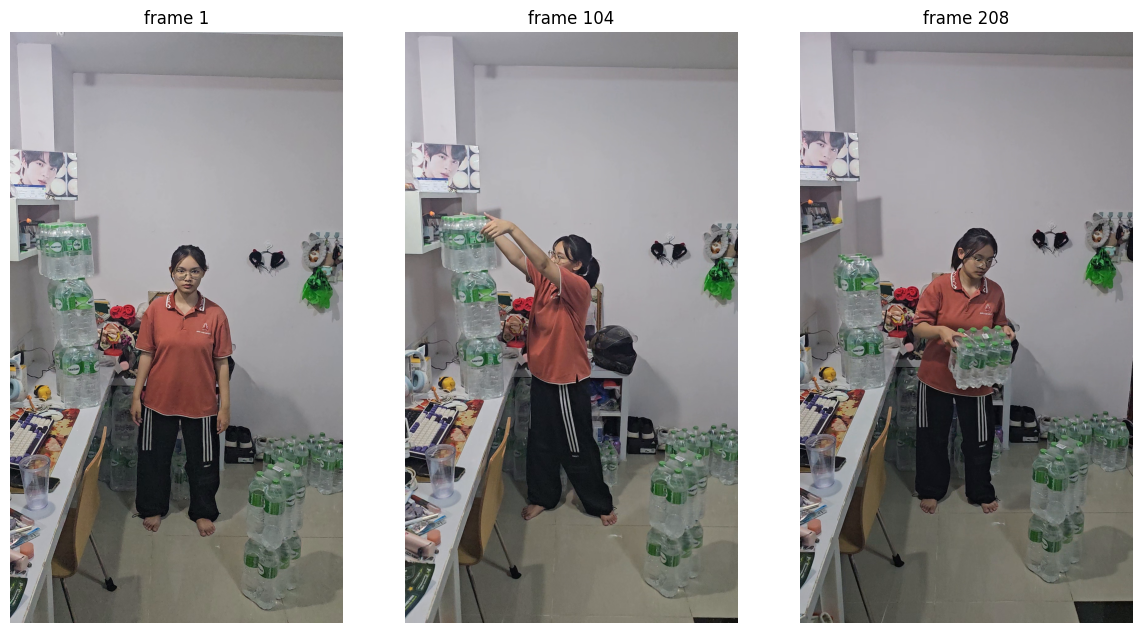

In [4]:
def open_video(path):
    # เปิดวิดีโอ คืน (cap, ข้อมูลวิดีโอ)
    cap = cv2.VideoCapture(str(path))
    info = {
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    }
    return cap, info


def read_frame(path, frame_number):
    # อ่านเฟรมที่ต้องการ (นับจาก 1)
    cap, _ = open_video(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number - 1)
    ok, frame = cap.read()
    cap.release()
    return frame


def show_images(images, titles, width=4):
    # แสดงภาพ BGR หลายภาพเรียงกัน
    fig, axes = plt.subplots(1, len(images), figsize=(width * len(images), width * 1.6))
    axes = np.atleast_1d(axes)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))     # BGR → RGB ก่อนแสดง
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


cap, VIDEO_INFO = open_video(VIDEO_PATH)
cap.release()
FPS, WIDTH, HEIGHT = VIDEO_INFO["fps"], VIDEO_INFO["width"], VIDEO_INFO["height"]
print(VIDEO_INFO, f"→ ยาว {VIDEO_INFO['frames'] / FPS:.1f} วินาที")

n = VIDEO_INFO["frames"]
show_images([read_frame(VIDEO_PATH, i) for i in [1, n // 3, 2 * n // 3]],
            [f"frame {i}" for i in [1, n // 3, 2 * n // 3]])

---
## ขั้นที่ ② · สกัดจุดพิกัดร่างกาย (Keypoints Extraction) ด้วย Function Call

**MediaPipe Pose Landmarker** คืน **33 จุด** ของร่างกาย 2 แบบ

| ผลลัพธ์ | ค่า | ความหมาย |
|---|---|---|
| `pose_landmarks` | `x`, `y` (0–1) | ตำแหน่งในภาพ → คูณด้วยขนาดภาพได้ **พิกเซล** |
| | `visibility`, `presence` | ความมั่นใจ → ใช้ `confidence = min(visibility, presence)` |
| `pose_world_landmarks` | `x`, `y`, `z` | **โครงร่าง 3 มิติ หน่วยเมตร** จุดกำเนิดที่กึ่งกลางสะโพก |

จุดที่ใช้บ่อย: `0` จมูก · `11/12` ไหล่ · `15/16` ข้อมือ · `17–20` นิ้วก้อย/นิ้วชี้ · `23/24` สะโพก · `25/26` เข่า · `27/28` ข้อเท้า · `29/30` ส้นเท้า · `31/32` ปลายเท้า

> ⚠️ ใช้โหมด `VIDEO` ซึ่งต้องส่ง **timestamp (มิลลิวินาที) ที่เพิ่มขึ้นทุกเฟรม** → ใช้ `เลขเฟรม × 1000 / fps`

In [5]:
def create_pose_detector():
    # สร้างตัวตรวจจับท่าทาง (สร้างครั้งเดียว ใช้ได้ทั้งคลิป)
    options = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(POSE_MODEL_PATH)),
        running_mode=mp_vision.RunningMode.VIDEO,
        num_poses=1)
    return mp_vision.PoseLandmarker.create_from_options(options)


def extract_keypoints(detector, frame, frame_index):
    # ② คืน xy (33, 2) พิกเซล · world (33, 3) เมตร · conf (33,)   (เป็น NaN ถ้าไม่พบคน)
    h, w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    timestamp_ms = int(frame_index * 1000 / FPS)
    result = detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb), timestamp_ms)

    xy = np.full((33, 2), np.nan)
    world = np.full((33, 3), np.nan)
    conf = np.full(33, np.nan)
    if result.pose_landmarks:
        for i, lm in enumerate(result.pose_landmarks[0]):
            xy[i] = [lm.x * w, lm.y * h]
            conf[i] = min(lm.visibility, lm.presence)
        for i, lm in enumerate(result.pose_world_landmarks[0]):
            world[i] = [lm.x, lm.y, lm.z]
    return xy, world, conf


# ทดลองกับเฟรมแรก
with create_pose_detector() as detector:
    xy0, world0, conf0 = extract_keypoints(detector, read_frame(VIDEO_PATH, 1), 0)
ids = [0, 11, 12, 15, 16, 23, 24, 27, 28]
pd.DataFrame({"x_px": xy0[ids, 0], "y_px": xy0[ids, 1], "X_m": world0[ids, 0], "Y_m": world0[ids, 1],
              "Z_m": world0[ids, 2], "confidence": conf0[ids]}, index=pd.Index(ids, name="id")).round(3)

,x_px,y_px,X_m,Y_m,Z_m,confidence
id,,,,,,
0,574.014,800.008,0.043,-0.598,-0.394,1.000
11,670.520,919.983,0.199,-0.450,-0.211,1.000
12,473.693,902.596,-0.137,-0.457,-0.209,1.000
15,690.696,1212.245,0.228,0.043,-0.210,0.958
16,408.804,1188.256,-0.231,-0.002,-0.252,0.959
23,610.203,1201.971,0.110,0.000,-0.002,1.000
24,502.724,1195.081,-0.110,-0.001,0.002,1.000
27,614.968,1543.151,0.128,0.689,0.302,0.984
28,471.418,1534.958,-0.126,0.680,0.295,0.984


---
## ขั้นที่ ③ · การติดตามและลดการสั่นไหวของพิกัด (Tracking and Smoothing)

keypoint ดิบ **สั่น** ทุกเฟรม บางเฟรมกระโดดผิดที่หรือหายไป เราจึงกรองแต่ละจุดด้วย

**(ก) Kalman filter** — จำตำแหน่งและความเร็วของจุด ทุกเฟรมทำ 2 อย่าง
1. **predict** ทายตำแหน่งเฟรมนี้จากตำแหน่ง + ความเร็วเดิม
2. **correct** ถ้าค่าที่วัดได้ "ดี" (confidence ≥ 0.5 · อยู่ในภาพ · ไม่กระโดดไกลเกิน `gate`) ให้ปรับค่าทายเข้าหาค่าวัด
   ถ้าไม่ดี ใช้ค่าทายแทนได้ไม่เกิน `MAX_PREDICT_FRAMES` เฟรม

**(ข) Moving average ย้อนหลัง** — เฉลี่ยตำแหน่งเฟรมนี้กับ `HISTORY_FRAMES` เฟรมก่อนหน้า (ใช้แต่อดีต เหมาะกับ real-time)

**(ค) โครงร่าง 3 มิติ** เฉลี่ยย้อนหลัง `WORLD_WINDOW` เฟรม

In [6]:
MIN_CONFIDENCE     = 0.5   # ค่าวัดที่ confidence ต่ำกว่านี้ไม่ใช้
MAX_PREDICT_FRAMES = 5     # ใช้ค่าทายแทนได้ติดกันกี่เฟรม
HISTORY_FRAMES     = 3     # moving average = เฟรมนี้ + 3 เฟรมก่อนหน้า
WORLD_WINDOW       = 5     # 👉 MODIFY — จำนวนเฟรมที่เฉลี่ยโครงร่าง 3 มิติ


def create_kalman(x, y):
    # Kalman filter แบบความเร็วคงที่  สถานะ = [x, y, vx, vy]  ค่าวัด = [x, y]
    kf = cv2.KalmanFilter(4, 2)
    kf.transitionMatrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], np.float32)
    kf.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], np.float32)
    acc = np.array([[0.5, 0], [0, 0.5], [1, 0], [0, 1]], np.float32)
    kf.processNoiseCov = 16.0 * acc @ acc.T                     # การเคลื่อนที่ไม่แน่นอนแค่ไหน
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 25.0  # ค่าวัดคลาดเคลื่อนประมาณ 5 px
    kf.errorCovPost = np.diag([25, 25, 400, 400]).astype(np.float32)
    kf.statePost = np.array([[x], [y], [0], [0]], np.float32)
    return kf


class PointTracker:
    # ติดตาม + ลดการสั่นของ keypoint 1 จุด

    def __init__(self, width, height):
        self.width, self.height = width, height
        self.gate = max(25.0, 0.04 * math.hypot(width, height))   # ระยะกระโดดสูงสุดที่ยอมรับ (px)
        self.kalman = None       # None = ยังไม่ได้เริ่มติดตาม
        self.missing = 0         # จำนวนเฟรมติดกันที่ไม่มีค่าวัดที่ดี
        self.history = []        # ตำแหน่งล่าสุด สำหรับ moving average

    def update(self, x, y, conf):
        # คืน (ตำแหน่งที่กรองแล้ว, วัดได้จริงในเฟรมนี้หรือไม่)
        good = conf >= MIN_CONFIDENCE and 0 <= x < self.width and 0 <= y < self.height   # NaN → False
        point, observed = None, False

        if self.kalman is None:                          # ยังไม่ได้ติดตาม → เริ่มเมื่อค่าวัดดี
            if good:
                self.kalman = create_kalman(x, y)
                point, observed = np.array([x, y]), True
        else:
            predicted = self.kalman.predict()[:2, 0]     # (ก-1) predict
            jump = math.hypot(x - predicted[0], y - predicted[1]) if good else 0
            if good and jump <= self.gate:               # (ก-2) correct ด้วยค่าวัด
                self.kalman.correct(np.array([[x], [y]], np.float32))
                point, observed = np.array([x, y]), True
                self.missing = 0
            else:                                        # ไม่มีค่าวัดที่ดี → ใช้ค่าทาย
                self.missing += 1
                inside = 0 <= predicted[0] < self.width and 0 <= predicted[1] < self.height
                if self.missing <= MAX_PREDICT_FRAMES and inside:
                    point = predicted
                else:                                    # หายนานเกินไป → เริ่มใหม่
                    self.kalman, self.missing, self.history = None, 0, []

        if point is None:
            return np.array([np.nan, np.nan]), False
        self.history = (self.history + [point])[-(HISTORY_FRAMES + 1):]   # (ข) moving average
        return np.mean(self.history, axis=0), observed


class PoseSmoother:
    # PointTracker 33 ตัว (สำหรับภาพ) + ค่าเฉลี่ยย้อนหลังของโครงร่าง 3 มิติ

    def __init__(self, width, height):
        self.trackers = [PointTracker(width, height) for _ in range(33)]
        self.world_history = deque(maxlen=WORLD_WINDOW)

    def update(self, xy, world, conf):
        xy_s = np.full((33, 2), np.nan)
        observed = np.zeros(33, dtype=bool)
        for i in range(33):
            xy_s[i], observed[i] = self.trackers[i].update(xy[i, 0], xy[i, 1], conf[i])
        self.world_history.append(world)
        world_s = np.nanmean(np.array(self.world_history), axis=0)    # (ค)
        return xy_s, world_s, observed

**ทดลอง:** ประมวลผล 150 เฟรมแรก เก็บไว้ใน `demo` เพื่อใช้ในขั้นที่ ④–⑧ แล้วเทียบข้อมือซ้าย (จุด 15) ก่อนและหลังกรอง

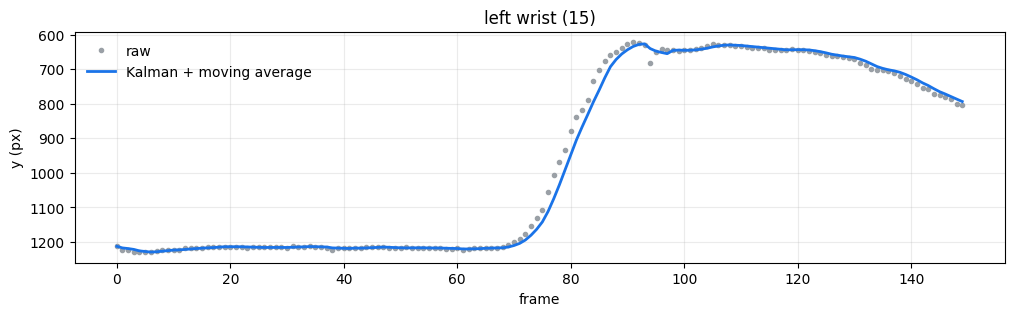

In [7]:
DEMO_FRAMES = 150
demo = {"frame": [], "xy_raw": [], "xy": [], "world": [], "observed": []}

cap, _ = open_video(VIDEO_PATH)
smoother = PoseSmoother(WIDTH, HEIGHT)
with create_pose_detector() as detector:
    for i in range(DEMO_FRAMES):
        ok, frame = cap.read()                                            # ①
        if not ok:
            break
        xy, world, conf = extract_keypoints(detector, frame, i)           # ②
        xy_s, world_s, observed = smoother.update(xy, world, conf)        # ③
        demo["frame"].append(frame)
        demo["xy_raw"].append(xy)
        demo["xy"].append(xy_s)
        demo["world"].append(world_s)
        demo["observed"].append(observed)
cap.release()

raw = np.array(demo["xy_raw"])[:, 15, 1]
smooth = np.array(demo["xy"])[:, 15, 1]
plt.figure(figsize=(12, 3))
plt.plot(raw, ".", color="#9aa0a6", label="raw")
plt.plot(smooth, color="#1a73e8", lw=2, label="Kalman + moving average")
plt.gca().invert_yaxis()                     # แกน y ของภาพชี้ลง → กลับแกนให้ "ยกขึ้น" เป็นเส้นขึ้น
plt.xlabel("frame"); plt.ylabel("y (px)"); plt.title("left wrist (15)")
plt.legend(frameon=False); plt.grid(alpha=0.25); plt.show()

---
## ขั้นที่ ④ · การวาดจุด Keypoints ลงบนเฟรมภาพ

วาดเส้นโครงกระดูกด้วย `cv2.line` และจุดด้วย `cv2.circle` — จุด **เขียว** = วัดได้จริง · **ส้ม** = ค่าที่ Kalman ทายแทน
(OpenCV ใช้สีแบบ **(B, G, R)**)

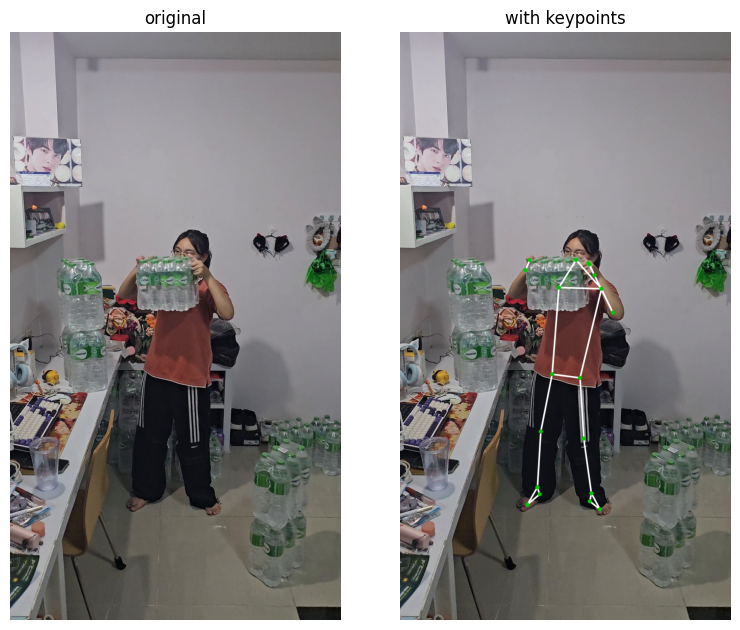

In [8]:
SKELETON = [(11, 12), (11, 23), (12, 24), (23, 24),                  # ลำตัว
            (11, 13), (13, 15), (15, 17), (15, 19),                  # แขนซ้าย
            (12, 14), (14, 16), (16, 18), (16, 20),                  # แขนขวา
            (23, 25), (25, 27), (27, 29), (27, 31), (29, 31),        # ขาซ้าย
            (24, 26), (26, 28), (28, 30), (28, 32), (30, 32),        # ขาขวา
            (0, 11), (0, 12)]                                        # ศีรษะ


def pt(p):
    # แปลงพิกัดทศนิยมเป็นจุดจำนวนเต็มสำหรับ OpenCV
    return (int(round(p[0])), int(round(p[1])))


def ui_scale(img):
    # ขนาดตัวอักษร/เส้น เทียบกับภาพกว้าง 720 px
    return img.shape[1] / 720


def draw_skeleton(img, xy_s, observed):
    # ④ วาดโครงกระดูกลงบนภาพ
    s = ui_scale(img)
    for a, b in SKELETON:
        if np.isfinite(xy_s[a]).all() and np.isfinite(xy_s[b]).all():
            cv2.line(img, pt(xy_s[a]), pt(xy_s[b]), (255, 255, 255), max(1, int(2 * s)), cv2.LINE_AA)
    for a, b in SKELETON:
        for p in (a, b):
            if np.isfinite(xy_s[p]).all():
                color = (0, 200, 0) if observed[p] else (0, 140, 255)
                cv2.circle(img, pt(xy_s[p]), max(2, int(4 * s)), color, -1, cv2.LINE_AA)
    return img


k = len(demo["frame"]) - 1
show_images([demo["frame"][k], draw_skeleton(demo["frame"][k].copy(), demo["xy"][k], demo["observed"][k])],
            ["original", "with keypoints"])

---
## ขั้นที่ ⑤ · การคำนวณมาตราส่วนเทียบเคียง (cm/pixel Ratio) และพิกัด 3 มิติ

ใช้ **ช่วงยืนตรงนิ่งต้นคลิป** (`CALIB_SECONDS` วินาที) กับ **ส่วนสูงจริง** สร้างเครื่องมือวัด ทำครั้งเดียวแล้วใช้ทั้งคลิป

### 5.1 สเกลในภาพ: ซม./พิกเซล
$$
\text{cm/px} = \frac{\text{ส่วนสูงจริง} \times 0.905}{\operatorname{median}(y_{\text{floor}} - y_{\text{nose}})}
$$
- $y_{\text{floor}}$ = ระดับพื้น = y ที่ต่ำที่สุดของส้นเท้า/ปลายเท้า · **0.905** = ระยะพื้นถึงจมูกเป็นสัดส่วนของส่วนสูง
- ระยะกล้องถึงผู้ยก $D = f \times \text{cm/px}$ โดย $f$ = ความยาวโฟกัส (พิกเซล) จากมุมมองกล้อง `CAMERA_FOV_DEG`

### 5.2 พิกัด 3 มิติของทุกจุด (หน่วย ซม.)
1. ขยายโครงร่าง 3 มิติของ MediaPipe (`world`) ให้สูงเท่าผู้ยกจริง → `world_scale`
2. **`cv2.solvePnP`** หาว่ากล้องมองโครงร่างนั้นจากมุมไหน (การหมุน $R$ และเลื่อน $t$) → ได้ **ความลึก $Z$** ของแต่ละจุด
3. รวมกับตำแหน่ง $(u, v)$ ในภาพ ด้วยสูตรกล้องรูเข็ม: $X = (u - c_x)Z/f$ · $Y = (v - c_y)Z/f$

### 5.3 กรอบพิกัดของร่างกาย
```
     มองจากด้านบน                              มองจากด้านข้าง
   hipL ●━━━━━━━━━━━━━● hipR  ← ระนาบสะโพก         │ up (แนวดิ่ง)
                 ┃ front                            │     ● กึ่งกลางมือ
                 ▼ (ตั้งฉากกับระนาบสะโพก)            │     ┆ V = ความสูงจากพื้น
                                             O ●────┘
                                    (กึ่งกลางข้อเท้า)   H = ระยะแนวราบ O → มือ
```
| ทิศ | ความหมาย |
|---|---|
| `up` | แนวดิ่ง = ทิศจากเท้าไปสะโพก **ขณะยืนตรง** (กล้องตั้งนิ่ง จึงคงที่ทั้งคลิป) |
| `side` | เส้นสะโพก ซ้าย→ขวา (ตัดส่วนที่เป็นแนวดิ่งออก) |
| `front` | ตั้งฉากกับทั้งสองทิศข้างบน = **ตั้งฉากกับระนาบสะโพก** หันไปทางปลายเท้า |
| `O` | **กึ่งกลางข้อเท้าทั้งสอง ที่ระดับพื้น** (จุดอ้างอิงของ NIOSH) — ระดับพื้นวัดครั้งเดียวตอนยืนนิ่ง |

ช่วงยืนนิ่งยังใช้วัด **ความสูงเข่า · เอว · ไหล่** (ขอบของ 4 แถวในตาราง · เอว = สะโพก + 0.30 × (ไหล่ − สะโพก))

In [9]:
NOSE_ABOVE_FOOT = 0.905     # พื้น→จมูก / ส่วนสูง
CALIB_SECONDS   = 1.5       # 👉 MODIFY — ช่วงยืนนิ่งต้นคลิป (วินาที)
CAMERA_FOV_DEG  = 70.0      # 👉 MODIFY — มุมมองกล้องตามด้านยาวของภาพ (มือถือทั่วไป 65–75°)
WAIST_FRACTION  = 0.30      # 👉 MODIFY — ตำแหน่งเอวระหว่างสะโพกกับไหล่
FEET = [29, 30, 31, 32]     # ส้นเท้า + ปลายเท้า (ใช้หาระดับพื้น)
LOWER = [27, 28, 29, 30, 31, 32]   # ข้อเท้า + ส้นเท้า + ปลายเท้า (ใช้หาแกนลำตัว เท้า→สะโพก)
PNP_POINTS = [0, 11, 12, 13, 14, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


def unit(v):
    # ทำเวกเตอร์ให้ยาว 1
    return v / np.linalg.norm(v)


def mean_point(points, ids):
    # จุดเฉลี่ยของหลาย landmark (ข้ามค่า NaN)
    return np.nanmean(points[ids], axis=0)


# ---------------------------------------------------------------- 5.1
def calc_cm_per_px(xy_frames, height_cm):
    # ซม. ต่อพิกเซล จากระยะพื้น→จมูกในภาพ
    distances = []
    for xy in xy_frames:
        floor_y = np.nanmax(xy[FEET, 1])
        distances.append(floor_y - xy[0, 1])
    return height_cm * NOSE_ABOVE_FOOT / np.nanmedian(distances)


def camera_matrix(width, height):
    # เมทริกซ์กล้องรูเข็ม K จาก FOV
    f = (max(width, height) / 2) / math.tan(math.radians(CAMERA_FOV_DEG) / 2)
    return np.array([[f, 0, width / 2], [0, f, height / 2], [0, 0, 1]])


# ---------------------------------------------------------------- 5.2
def calc_world_scale(world_frames, height_cm):
    # ตัวคูณที่ทำให้โครงร่าง 3 มิติสูง (พื้น→จมูก) เท่าผู้ยกจริง
    heights = []
    for world in world_frames:
        axis = unit(mean_point(world, [23, 24]) - mean_point(world, LOWER))  # เท้า→สะโพก
        heights.append(np.nanmax((world[0] - world[FEET]) @ axis) * 100)    # พื้น→จมูก (ซม.)
    return height_cm * NOSE_ABOVE_FOOT / np.nanmedian(heights)


def solve_camera_pose(P, xy, observed, K, previous=None):
    # หา R, t ที่ทำให้จุด 3 มิติ P ฉายลงภาพแล้วตรงกับ xy มากที่สุด
    ids = [i for i in PNP_POINTS if observed[i]]
    if len(ids) < 6:
        return None
    if previous is None:
        ok, rvec, tvec = cv2.solvePnP(P[ids], xy[ids], K, None)
    else:                                                    # ใช้ผลเฟรมก่อนเป็นจุดเริ่ม → นิ่งและเร็ว
        ok, rvec, tvec = cv2.solvePnP(P[ids], xy[ids], K, None,
                                      previous["rvec"].copy(), previous["tvec"].copy(), True)
    if not ok:
        return None
    R, _ = cv2.Rodrigues(rvec)
    return {"R": R, "t": tvec.ravel(), "rvec": rvec, "tvec": tvec}


def to_camera_3d(xy, P, pose, K):
    # ตำแหน่งในภาพ (u, v) + ความลึก Z จากโครงร่าง → พิกัดกล้อง 3 มิติ (33, 3) ซม.
    P_cam = P @ pose["R"].T + pose["t"]                      # โครงร่างในพิกัดกล้อง
    Z = P_cam[:, 2]
    X = (xy[:, 0] - K[0, 2]) * Z / K[0, 0]
    Y = (xy[:, 1] - K[1, 2]) * Z / K[1, 1]
    C = np.column_stack([X, Y, Z])
    missing = np.isnan(xy[:, 0])
    C[missing] = P_cam[missing]                              # จุดที่ไม่เห็นในภาพ → ใช้โครงร่างแทน
    return C


def project(points, K):
    # จุดในพิกัดกล้อง (…, 3) → ตำแหน่งในภาพ (…, 2) พิกเซล
    points = np.asarray(points, dtype=float)
    u = K[0, 0] * points[..., 0] / points[..., 2] + K[0, 2]
    v = K[1, 1] * points[..., 1] / points[..., 2] + K[1, 2]
    return np.stack([u, v], axis=-1)


# ---------------------------------------------------------------- 5.3
def body_frame(C, up, floor=None):
    # กรอบพิกัดร่างกาย: O, up, side, front  (floor = จุดบนพื้นจาก calibrate)
    ankle = mean_point(C, [27, 28])
    side = C[24] - C[23]
    side = unit(side - (side @ up) * up)                     # เส้นสะโพกในแนวราบ
    front = unit(np.cross(side, up))                         # ตั้งฉากกับระนาบสะโพก
    toe, heel = mean_point(C, [31, 32]), mean_point(C, [29, 30])
    if (toe - heel) @ front < 0:                             # ให้ front ชี้ไปทางปลายเท้า
        front = -front
    if floor is None:
        drop = np.nanmin((C[FEET] - ankle) @ up)             # พื้น = จุดเท้าที่ต่ำที่สุด
    else:
        drop = (floor - ankle) @ up
    O = ankle + up * drop                                    # กึ่งกลางข้อเท้า ที่ระดับพื้น
    if not (np.isfinite(O).all() and np.isfinite(front).all()):
        return None
    return {"O": O, "up": up, "side": side, "front": front}


def body_coords(p, body):
    # จุด 3 มิติ → (ด้านหน้า, ความสูง, ด้านข้าง) ซม. เทียบกับ O
    d = p - body["O"]
    return d @ body["front"], d @ body["up"], d @ body["side"]


def twist_angle(world):
    # มุม (มีเครื่องหมาย) ระหว่างเส้นไหล่กับเส้นสะโพก รอบแกนลำตัว — ใช้ในขั้นที่ ⑦
    axis = unit(mean_point(world, [23, 24]) - mean_point(world, LOWER))
    hip = world[24] - world[23]
    shoulder = world[12] - world[11]
    hip = unit(hip - (hip @ axis) * axis)
    shoulder = unit(shoulder - (shoulder @ axis) * axis)
    return math.degrees(math.atan2(np.cross(hip, shoulder) @ axis, hip @ shoulder))


# ---------------------------------------------------------------- รวมทุกอย่าง
def calibrate(samples, height_cm, width, height):
    # ⑤ samples = รายการ {"xy", "world", "observed"} ของช่วงยืนนิ่ง → dict calib
    calib = {"height_cm": height_cm}
    calib["cm_per_px"] = calc_cm_per_px([s["xy"] for s in samples], height_cm)               # 5.1
    calib["K"] = camera_matrix(width, height)
    calib["camera_dist_cm"] = calib["K"][0, 0] * calib["cm_per_px"]
    calib["world_scale"] = calc_world_scale([s["world"] for s in samples], height_cm)          # 5.2

    C_list, axes, pose = [], [], None                                                        # พิกัด 3 มิติของแต่ละเฟรม
    for s in samples:
        P = s["world"] * 100 * calib["world_scale"]
        pose = solve_camera_pose(P, s["xy"], s["observed"], calib["K"], pose)
        if pose is None:
            continue
        C = to_camera_3d(s["xy"], P, pose, calib["K"])
        C_list.append(C)
        axes.append(unit(mean_point(C, [23, 24]) - mean_point(C, LOWER)))
    calib["up"] = unit(np.mean(axes, axis=0))                                                # 5.3 แนวดิ่ง
    floors = []                                                                              # จุดบนพื้น
    for C in C_list:
        body = body_frame(C, calib["up"])
        if body is not None:
            floors.append(body["O"])
    calib["floor"] = np.median(floors, axis=0)

    knee, hip, shoulder = [], [], []                                                         # ระดับเข่า/สะโพก/ไหล่
    for C in C_list:
        body = body_frame(C, calib["up"], calib["floor"])
        if body is None:
            continue
        knee.append(body_coords(mean_point(C, [25, 26]), body)[1])
        hip.append(body_coords(mean_point(C, [23, 24]), body)[1])
        shoulder.append(body_coords(mean_point(C, [11, 12]), body)[1])
    calib["knee_cm"] = np.median(knee)
    calib["shoulder_cm"] = np.median(shoulder)
    calib["waist_cm"] = np.median(hip) + WAIST_FRACTION * (calib["shoulder_cm"] - np.median(hip))
    calib["twist_baseline"] = np.nanmedian([twist_angle(s["world"]) for s in samples])       # ใช้ในขั้นที่ ⑦
    return calib


CALIB_FRAMES = int(round(CALIB_SECONDS * FPS))
samples = [{"xy": demo["xy"][i], "world": demo["world"][i], "observed": demo["observed"][i]}
           for i in range(CALIB_FRAMES)]
CALIB = calibrate(samples, SUBJECT_HEIGHT_CM, WIDTH, HEIGHT)

for key in ["cm_per_px", "camera_dist_cm", "world_scale", "knee_cm", "waist_cm", "shoulder_cm"]:
    print(f"{key:15s} = {CALIB[key]:.3f}")

cm_per_px       = 0.178
camera_dist_cm  = 244.556
world_scale     = 0.969
knee_cm         = 42.282
waist_cm        = 90.700
shoulder_cm     = 126.065


**ใช้กับทุกเฟรมของ demo** (หลัง calibrate แล้ว ทุกเฟรมทำ 3 บรรทัดนี้) แล้ว **ตรวจด้วยตา** โดยฉายจุด $O$ แนวดิ่ง ทิศ `front` และระดับเข่า/เอว/ไหล่กลับลงภาพ

ระยะกล้อง: จาก cm/px = 245 ซม. · จาก solvePnP = 235 ซม. (ควรใกล้กัน)


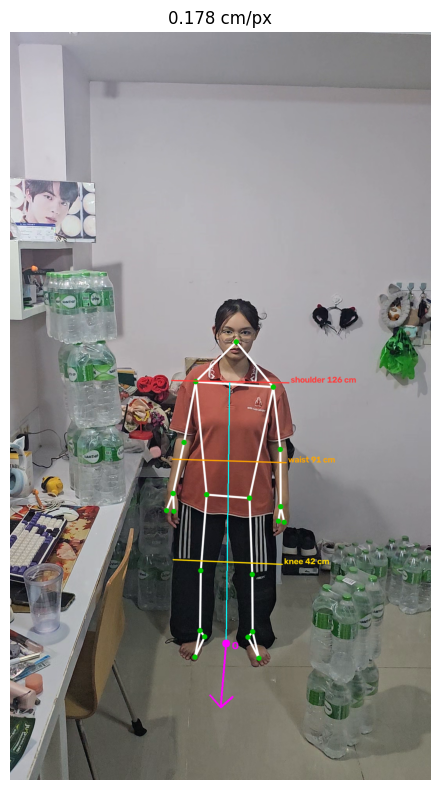

In [10]:
demo["C"] = []
pose = None
for xy, world, observed in zip(demo["xy"], demo["world"], demo["observed"]):
    P = world * 100 * CALIB["world_scale"]                            # โครงร่าง 3 มิติ (ซม.)
    pose = solve_camera_pose(P, xy, observed, CALIB["K"], pose)       # ท่าทางกล้อง
    demo["C"].append(to_camera_3d(xy, P, pose, CALIB["K"]) if pose else None)
print(f"ระยะกล้อง: จาก cm/px = {CALIB['camera_dist_cm']:.0f} ซม. · จาก solvePnP = {pose['t'][2]:.0f} ซม. (ควรใกล้กัน)")


def draw_body_frame(img, C, calib):
    # วาด O · แนวดิ่ง · ลูกศร front · ระดับเข่า/เอว/ไหล่
    body = body_frame(C, calib["up"], calib["floor"])
    K, s = calib["K"], ui_scale(img)
    O, up, side, front = body["O"], body["up"], body["side"], body["front"]
    cv2.line(img, pt(project(O, K)), pt(project(O + up * calib["shoulder_cm"], K)), (255, 255, 0), 2)
    cv2.arrowedLine(img, pt(project(O, K)), pt(project(O + front * 40, K)), (255, 0, 255), 3, tipLength=0.25)
    cv2.circle(img, pt(project(O, K)), int(7 * s), (255, 0, 255), -1)
    cv2.putText(img, "O", pt(project(O, K) + 10 * s), cv2.FONT_HERSHEY_SIMPLEX, 0.6 * s, (255, 0, 255), 2)
    for name, color in [("knee", (0, 215, 255)), ("waist", (0, 165, 255)), ("shoulder", (60, 60, 255))]:
        level = O + up * calib[name + "_cm"]
        a, b = project(level - side * 25, K), project(level + side * 25, K)
        cv2.line(img, pt(a), pt(b), color, 2, cv2.LINE_AA)
        cv2.putText(img, f"{name} {calib[name + '_cm']:.0f} cm", pt((max(a[0], b[0]) + 5, a[1])),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5 * s, color, 2)
    return img


k = CALIB_FRAMES - 1
img = draw_skeleton(demo["frame"][k].copy(), demo["xy"][k], demo["observed"][k])
show_images([draw_body_frame(img, demo["C"][k], CALIB)], [f"{CALIB['cm_per_px']:.3f} cm/px"], width=5)

---
## ขั้นที่ ⑥ · มุมการหันของร่างกายเทียบกับระนาบกล้อง (Orientation Angle)

มองจาก **ด้านบนศีรษะ** ดูว่าเส้นสะโพก (ซ้าย→ขวา) ทำมุมกับระนาบภาพเท่าไร
```
      Z ↑ ไกลกล้อง            θ = 0°   หันหน้าเข้าหา/หันหลังให้กล้อง
        │   ╱ เส้นสะโพก       θ = 90°  หันข้างให้กล้อง
        │ ╱ yaw
  ──────┼──────► X            yaw = atan2(ΔZ, ΔX)   แล้วพับให้อยู่ในช่วง 0–90°
      ▲ กล้อง
```

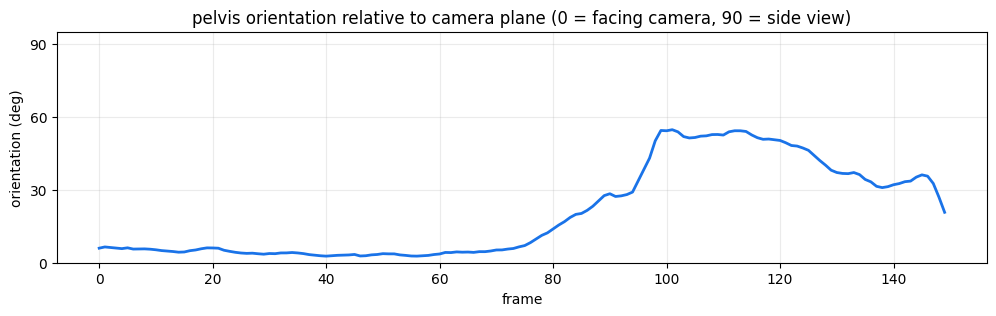

In [11]:
def orientation_angle(C):
    # ⑥ มุมระหว่างเส้นสะโพกกับระนาบกล้อง (0 = หันเข้ากล้อง, 90 = หันข้าง)
    d = C[24] - C[23]
    yaw = abs(math.degrees(math.atan2(d[2], d[0])))    # 0…180
    return min(yaw, 180 - yaw)                         # พับเป็น 0…90


orient_demo = [orientation_angle(C) if C is not None else np.nan for C in demo["C"]]
plt.figure(figsize=(12, 3))
plt.plot(orient_demo, color="#1a73e8", lw=2)
plt.ylim(0, 95); plt.yticks([0, 30, 60, 90])
plt.xlabel("frame"); plt.ylabel("orientation (deg)"); plt.grid(alpha=0.25)
plt.title("pelvis orientation relative to camera plane (0 = facing camera, 90 = side view)"); plt.show()

> ✅ **ตรวจด้วยตนเอง:** ถ้าถ่ายด้านข้างตามโปรโตคอล ค่าควรเข้าใกล้ 90° — ยิ่งต่ำกว่ามาก แปลว่ากล้องเบี่ยงจากแนวตั้งฉากมาก (เทียบรหัส R04 ใน QC sheet)
> ระยะมือในขั้นที่ ⑧ วัดใน 3 มิติ จึงยังถูกต้องแม้มุมนี้ไม่ใช่ 90°

---
## ขั้นที่ ⑦ · มุมการบิดตัวของร่างกายขณะยกวัตถุ (Twist Angle)

**การบิดตัว** = ไหล่หมุนไปคนละทางกับสะโพก (เท้าอยู่กับที่) วัดจากโครงร่าง 3 มิติ **รอบแกนลำตัว** จึงไม่ขึ้นกับมุมกล้อง
(ฟังก์ชัน `twist_angle()` อยู่ในขั้นที่ ⑤ เพราะใช้หา baseline ตอน calibrate)

$$
\text{twist} = \big|\, \text{มุม(ไหล่, สะโพก)} - \text{baseline} \,\big|
$$
baseline = มุมเดียวกันขณะยืนตรง · ถ้า twist > `TWIST_WARN_DEG` (45°) ถือว่า **บิดตัวชัดเจน** (เงื่อนไข `T1`) แสดงเป็นสีแดง

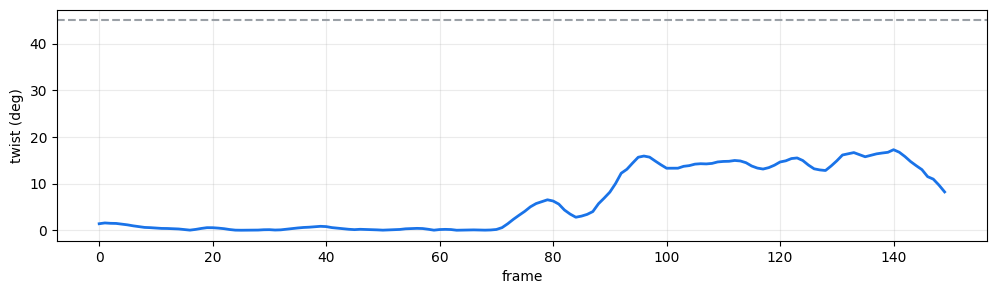

In [12]:
TWIST_WARN_DEG = 45.0     # 👉 MODIFY


def twist_from_baseline(world, calib):
    # ⑦ มุมบิดตัว (องศา, ค่าบวก) เทียบกับท่ายืนตรง
    diff = twist_angle(world) - calib["twist_baseline"]
    diff = (diff + 180) % 360 - 180                    # ให้อยู่ในช่วง −180…180
    return abs(diff)


twist_demo = [twist_from_baseline(w, CALIB) for w in demo["world"]]
plt.figure(figsize=(12, 3))
plt.plot(twist_demo, color="#1a73e8", lw=2)
plt.axhline(TWIST_WARN_DEG, color="#9aa0a6", ls="--")
plt.xlabel("frame"); plt.ylabel("twist (deg)"); plt.grid(alpha=0.25); plt.show()

---
## ขั้นที่ ⑧ · ตารางเกณฑ์น้ำหนักปลอดภัย 3×4 (Perspective Transform)

### 8.1 ตำแหน่งมือแบบ NIOSH และช่องในตาราง
> **H** = ระยะแนวราบจาก **กึ่งกลางข้อเท้า (O)** ถึงจุดบนพื้นใต้ **กึ่งกลางมือทั้งสองข้าง**
> **V** = ความสูงของกึ่งกลางมือจากพื้น

1. กึ่งกลางมือแต่ละข้าง = เฉลี่ยข้อมือ + นิ้วก้อย + นิ้วชี้ (15/17/19 และ 16/18/20) แล้วเฉลี่ยสองข้าง (เห็นข้างเดียว → ใช้ข้างนั้น)
2. `body_coords()` → ด้านหน้า, ความสูง (V), ด้านข้าง  →  $H = \sqrt{\text{ด้านหน้า}^2 + \text{ด้านข้าง}^2}$
3. **คอลัมน์** จาก H : Near < 17.8 ซม. ≤ Mild < 30.5 ซม. ≤ Extended
4. **แถว** จาก V : Below Knee < เข่า ≤ Knee–Waist < เอว ≤ Waist–Shoulder < ไหล่ ≤ Above Shoulder

> 💡 NIOSH กำหนด H ต่ำสุด 25 ซม. เพราะลำตัวขวางอยู่ — ถือกล่องชิดท้องตามปกติจึงได้ H ประมาณ 25–30 ซม.

In [13]:
REACH_LIMITS_CM = [7 * 2.54, 12 * 2.54]                        # 17.78, 30.48 ซม.
ROW_NAMES = ["Above Shoulder", "Waist-Shoulder", "Knee-Waist", "Below Knee"]
COL_NAMES = ["Near", "Mild", "Extended"]
WEIGHT_LIMITS_KG = [[29, 18, 14],      # Above Shoulder
                    [32, 23, 18],      # Waist to Shoulder
                    [41, 25, 18],      # Knee to Waist  (สูงสุด)
                    [31, 23, 16]]      # Below Knee
LEFT_HAND, RIGHT_HAND = [15, 17, 19], [16, 18, 20]


def table_row(v_cm, calib):
    # แถวของตารางจากความสูงมือ
    if v_cm >= calib["shoulder_cm"]:
        return 0
    if v_cm >= calib["waist_cm"]:
        return 1
    if v_cm >= calib["knee_cm"]:
        return 2
    return 3


def table_col(h_cm):
    # คอลัมน์ของตารางจากระยะ H
    if h_cm < REACH_LIMITS_CM[0]:
        return 0
    if h_cm < REACH_LIMITS_CM[1]:
        return 1
    return 2


def measure_hands(C, xy, calib):
    # ⑧-1 คืน H, V, ช่องในตาราง และน้ำหนักสูงสุด (None ถ้าวัดไม่ได้)
    body = body_frame(C, calib["up"], calib["floor"])
    if body is None:
        return None
    hands_3d = np.nanmean([mean_point(C, LEFT_HAND), mean_point(C, RIGHT_HAND)], axis=0)
    hands_px = np.nanmean([mean_point(xy, LEFT_HAND), mean_point(xy, RIGHT_HAND)], axis=0)
    if np.isnan(hands_3d).any():
        return None
    if np.isnan(hands_px).any():                            # มือหลุดจากภาพ → ฉายจาก 3 มิติแทน
        hands_px = project(hands_3d, calib["K"])

    front, v_cm, side = body_coords(hands_3d, body)
    h_cm = math.hypot(front, side)                          # NIOSH H
    row, col = table_row(v_cm, calib), table_col(h_cm)
    return {"H": h_cm, "V": v_cm, "front": front, "side": side,
            "row": row, "col": col, "limit_kg": WEIGHT_LIMITS_KG[row][col],
            "hands_px": hands_px, "body": body,
            "direction": -1 if front < -REACH_LIMITS_CM[0] else 1}   # มือหลังข้อเท้าชัดเจน → ตารางยื่นไปด้านหลัง


measures = [measure_hands(C, xy, CALIB) if C is not None else None for C, xy in zip(demo["C"], demo["xy"])]
H_demo = [m["H"] if m and i >= CALIB_FRAMES else -1 for i, m in enumerate(measures)]
K_DEMO = int(np.argmax(H_demo))                             # เฟรมที่มือยื่นไกลที่สุด
m = measures[K_DEMO]
print(f"frame {K_DEMO + 1}: H = {m['H']:.1f} ซม. · V = {m['V']:.1f} ซม. "
      f"→ {ROW_NAMES[m['row']]} | {COL_NAMES[m['col']]} → น้ำหนักสูงสุด {m['limit_kg']} kg")

frame 113: H = 46.2 ซม. · V = 165.7 ซม. → Above Shoulder | Extended → น้ำหนักสูงสุด 14 kg


### 8.2 วาดตารางด้วย Perspective Transform

ตารางเป็น **แผ่นเรียบ** ที่มีแนวดิ่ง `up` และทิศ `front` อยู่ในแผ่น → **ตั้งฉากกับระนาบสะโพกเสมอ**
ขอบด้านลำตัวอยู่เหนือกึ่งกลางข้อเท้าพอดี (H = 0)

1. `make_table_image()` วาดตารางแบนบนภาพเปล่า (1 ซม. = `PX_PER_CM` พิกเซล)
2. คำนวณมุมทั้ง 4 ของตารางใน 3 มิติ: $O$ · $O + \text{front}\cdot R$ · $O + \text{front}\cdot R + \text{up}\cdot T$ · $O + \text{up}\cdot T$
3. `project()` ฉายทั้ง 4 มุมลงภาพ แล้ว **`cv2.getPerspectiveTransform`** (4 คู่จุด) หาเมทริกซ์ 3×3
4. **`cv2.warpPerspective`** พาภาพตารางไปวางบนวิดีโอ — ขอบที่ไกลกล้องจะดูเล็กกว่า เหมือนแผ่นป้ายจริงในฉาก

จุดสีขาวบนตาราง = ตำแหน่ง (H, V) ของกึ่งกลางมือ · ป้ายสีเหลือง = น้ำหนักสูงสุด ณ ตำแหน่งนั้น

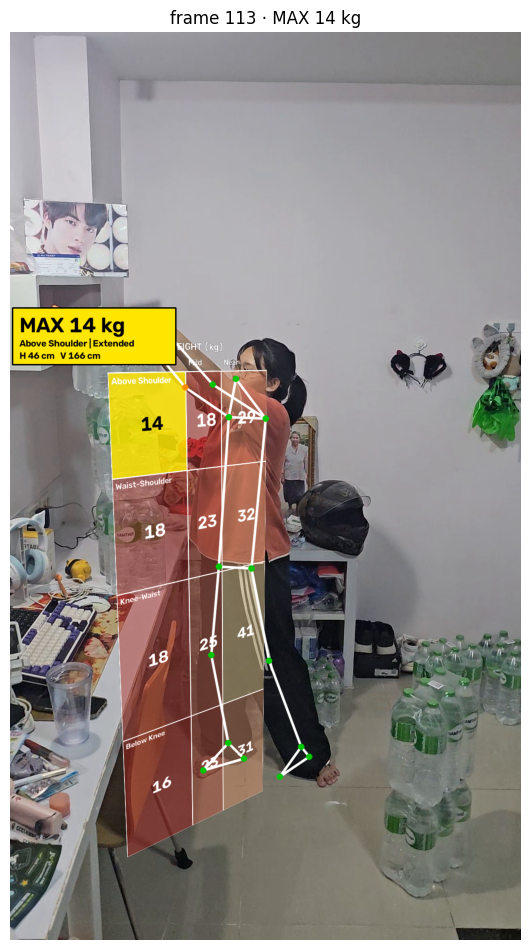

In [15]:
TABLE_LENGTH_CM = 55.0     # 👉 MODIFY — ความยาวตารางด้านหน้า (ซม.)
ABOVE_MARGIN_CM = 30.0     # ความสูงของแถว Above Shoulder เหนือไหล่
HEADER_CM       = 10.0     # แถบหัวคอลัมน์
PX_PER_CM       = 8        # ความละเอียดของภาพตาราง
CELL_ALPHA      = 0.45     # 👉 MODIFY — ความทึบของช่อง


def cell_color(kg):
    # สีเดียวไล่ความเข้ม: น้ำหนักมาก (ปลอดภัยกว่า) = ครีมอ่อน · น้อย = แดงเข้ม
    t = (41 - kg) / (41 - 14)
    light, dark = np.array([160, 225, 255]), np.array([20, 20, 170])
    return tuple(int(c) for c in light + (dark - light) * t)


def make_table_image(calib, highlight, axis_on_left):
    # ⑧-2 วาดตารางแบน: คืน (ภาพสี, ภาพความทึบ 0–1)
    top_cm = calib["shoulder_cm"] + ABOVE_MARGIN_CM + HEADER_CM
    w, h = int(TABLE_LENGTH_CM * PX_PER_CM), int(top_cm * PX_PER_CM)
    color = np.zeros((h, w, 3), np.uint8)
    alpha_uint8 = np.zeros((h, w), np.uint8)

    col_edges = [0, REACH_LIMITS_CM[0], REACH_LIMITS_CM[1], TABLE_LENGTH_CM]            # ซม. จากลำตัว
    row_edges = [calib["shoulder_cm"] + ABOVE_MARGIN_CM, calib["shoulder_cm"],
                 calib["waist_cm"], calib["knee_cm"], 0]                               # ซม. จากพื้น (บน→ล่าง)
    font = cv2.FONT_HERSHEY_SIMPLEX

    def to_x(cm):                     # ซม. จากลำตัว → x บนภาพตาราง
        x = int(cm * PX_PER_CM)
        return x if axis_on_left else w - x


    def to_y(cm):                     # ซม. จากพื้น → y บนภาพตาราง
        return int((top_cm - cm) * PX_PER_CM)


    def write(text, pos, size, thick, rgb=(255, 255, 255)):
        cv2.putText(color, text, pos, font, size, rgb, thick, cv2.LINE_AA)
        cv2.putText(alpha_uint8, text, pos, font, size, 255, thick, cv2.LINE_AA)

    for r in range(4):
        for c in range(3):
            x0, x1 = sorted([to_x(col_edges[c]), to_x(col_edges[c + 1])])
            y0, y1 = to_y(row_edges[r]), to_y(row_edges[r + 1])
            kg = WEIGHT_LIMITS_KG[r][c]
            is_hand_cell = (r, c) == highlight
            cv2.rectangle(color, (x0, y0), (x1, y1), (0, 230, 255) if is_hand_cell else cell_color(kg), -1)

            # กำหนดค่าความทึบลงใน alpha_uint8 (0-255) ชั่วคราวก่อน
            val = int(255 * (0.85 if is_hand_cell else CELL_ALPHA))
            alpha_uint8[y0:y1, x0:x1] = val

            cv2.rectangle(color, (x0, y0), (x1, y1), (255, 255, 255), 2)
            cv2.rectangle(alpha_uint8, (x0, y0), (x1, y1), 255, 2)
            write(str(kg), ((x0 + x1) // 2 - 22, (y0 + y1) // 2 + 15), 1.6, 4,
                  (0, 0, 0) if is_hand_cell else (255, 255, 255))
        x_label = 8 if not axis_on_left else w - 190
        write(ROW_NAMES[r], (x_label, to_y(row_edges[r]) + 26), 0.7, 2)
    for c in range(3):
        x0, x1 = sorted([to_x(col_edges[c]), to_x(col_edges[c + 1])])
        write(COL_NAMES[c], (x0 + 8, to_y(row_edges[0]) - 14), 0.7, 2)
    write("MAX WEIGHT (kg)", (w // 2 - 120, 30), 0.8, 2)

    # แปลง alpha_uint8 กลับเป็น float32 ในช่วง 0.0 - 1.0
    alpha = alpha_uint8.astype(np.float32) / 255.0
    return color, alpha


def draw_weight_table(img, calib, m):
    # ⑧-3 ฉายมุมตาราง 3 มิติลงภาพ แล้ว warpPerspective ภาพตารางลงไป
    body, K = m["body"], calib["K"]
    O, up, front = body["O"], body["up"], body["front"] * m["direction"]
    top_cm = calib["shoulder_cm"] + ABOVE_MARGIN_CM + HEADER_CM
    corners_3d = np.array([O,                                               # ล่าง-ลำตัว
                           O + front * TABLE_LENGTH_CM,                     # ล่าง-ปลาย
                           O + front * TABLE_LENGTH_CM + up * top_cm,       # บน-ปลาย
                           O + up * top_cm])                                # บน-ลำตัว
    if (corners_3d[:, 2] < 10).any():                                       # อยู่หลังกล้อง → ไม่วาด
        return img
    corners_px = project(corners_3d, K).astype(np.float32)
    if abs(cv2.contourArea(corners_px)) < 0.002 * img.shape[0] * img.shape[1]:
        return img                                                          # แผ่นหันสันเข้ากล้อง → ไม่วาด

    axis_on_left = corners_px[1, 0] >= corners_px[0, 0]                     # ตารางยื่นไปทางขวาของภาพ?
    table, alpha = make_table_image(calib, (m["row"], m["col"]), axis_on_left)
    th, tw = alpha.shape
    x_body, x_end = (0, tw) if axis_on_left else (tw, 0)
    table_corners = np.float32([[x_body, th], [x_end, th], [x_end, 0], [x_body, 0]])

    M = cv2.getPerspectiveTransform(table_corners, corners_px)              # เมทริกซ์ 3×3
    size = (img.shape[1], img.shape[0])
    warped = cv2.warpPerspective(table, M, size)
    warped_alpha = cv2.warpPerspective(alpha, M, size)[:, :, None]
    img[:] = (img * (1 - warped_alpha) + warped * warped_alpha).astype(np.uint8)
    return img


def draw_hand_label(img, calib, m):
    # ⑧-4 จุด (H, V) บนตาราง + ป้ายน้ำหนักสูงสุด
    body, K, s = m["body"], calib["K"], ui_scale(img)
    O, up, front = body["O"], body["up"], body["front"] * m["direction"]
    on_table = project(O + front * m["H"] + up * m["V"], K)                 # (H, V) บนแผ่นตาราง
    hands = m["hands_px"]
    cv2.line(img, pt(hands), pt(on_table), (255, 255, 255), max(1, int(2 * s)), cv2.LINE_AA)
    cv2.circle(img, pt(on_table), int(7 * s), (255, 255, 255), -1, cv2.LINE_AA)
    cv2.circle(img, pt(hands), int(16 * s), (0, 230, 255), max(2, int(3 * s)), cv2.LINE_AA)

    # ป้ายวางที่ขอบปลายตาราง ระดับเดียวกับมือ
    anchor = project(O + front * (TABLE_LENGTH_CM + 3) + up * m["V"], K)
    box_w, box_h = int(230 * s), int(80 * s)
    x0 = anchor[0] if anchor[0] >= project(O, K)[0] else anchor[0] - box_w
    x0 = int(np.clip(x0, 5, img.shape[1] - box_w - 5))
    y0 = int(np.clip(anchor[1] - box_h / 2, 5, img.shape[0] - box_h - 5))
    cv2.line(img, pt(on_table), (x0 + box_w // 2, y0 + box_h // 2), (0, 230, 255), max(2, int(3 * s)))
    cv2.rectangle(img, (x0, y0), (x0 + box_w, y0 + box_h), (0, 230, 255), -1)
    cv2.rectangle(img, (x0, y0), (x0 + box_w, y0 + box_h), (0, 0, 0), 2)
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, f"MAX {m['limit_kg']} kg", (x0 + int(10 * s), y0 + int(35 * s)), font, 1.0 * s,
                (0, 0, 0), max(2, int(3 * s)), cv2.LINE_AA)
    cv2.putText(img, f"{ROW_NAMES[m['row']]} | {COL_NAMES[m['col']]}", (x0 + int(10 * s), y0 + int(55 * s)),
                font, 0.45 * s, (0, 0, 0), max(1, int(1.5 * s)), cv2.LINE_AA)
    cv2.putText(img, f"H {m['H']:.0f} cm   V {m['V']:.0f} cm", (x0 + int(10 * s), y0 + int(72 * s)),
                font, 0.45 * s, (0, 0, 0), max(1, int(1.5 * s)), cv2.LINE_AA)
    return img


# ลำดับการวาด: ตาราง (ล่างสุด) → โครงกระดูก → ป้ายน้ำหนัก (บนสุด)
img = draw_weight_table(demo["frame"][K_DEMO].copy(), CALIB, m)
img = draw_skeleton(img, demo["xy"][K_DEMO], demo["observed"][K_DEMO])
img = draw_hand_label(img, CALIB, m)
show_images([img], [f"frame {K_DEMO + 1} · MAX {m['limit_kg']} kg"], width=6)

---
## ขั้นที่ ⑨ · รวมทุกขั้นแล้วบันทึกวิดีโอผลลัพธ์ (Write Video)

`run_pipeline()` ทำขั้น ①–⑧ ทีละเฟรมในลูปเดียว แล้วเขียนเฟรมด้วย `cv2.VideoWriter`
- ช่วง `CALIB_SECONDS` แรก: เก็บเฟรมไว้ calibrate (แสดง "CALIBRATING")
- หลังจากนั้น: หาท่าทางกล้อง → พิกัด 3 มิติ → มุมหัน · มุมบิด · H/V · ตาราง

ฟังก์ชันคืน **ตารางค่ารายเฟรม** (บันทึกเป็น CSV ด้วย)

In [16]:
def draw_info_panel(img, lines):
    # แผงข้อความมุมซ้ายบน: lines = [(ข้อความ, สี), ...]
    s = ui_scale(img)
    line_h = int(26 * s)
    overlay = img.copy()
    cv2.rectangle(overlay, (0, 0), (int(360 * s), int(15 * s) + line_h * len(lines)), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.55, img, 0.45, 0, dst=img)
    for i, (text, color) in enumerate(lines):
        cv2.putText(img, text, (int(10 * s), int(28 * s) + i * line_h), cv2.FONT_HERSHEY_SIMPLEX,
                    0.55 * s, color, max(1, int(1.5 * s)), cv2.LINE_AA)
    return img


def run_pipeline(video_path, out_path, height_cm, max_frames=None):
    cap, info = open_video(video_path)
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), info["fps"],
                             (info["width"], info["height"]))
    smoother = PoseSmoother(info["width"], info["height"])
    n_calib = int(round(CALIB_SECONDS * info["fps"]))
    calib, samples, pose = None, [], None
    records = []
    WHITE, YELLOW, RED = (255, 255, 255), (0, 230, 255), (80, 80, 255)

    with create_pose_detector() as detector:
        i = 0
        while max_frames is None or i < max_frames:
            ok, frame = cap.read()                                             # ① อ่านเฟรม
            if not ok:
                break
            xy, world, conf = extract_keypoints(detector, frame, i)            # ② keypoint
            xy_s, world_s, observed = smoother.update(xy, world, conf)         # ③ ลดการสั่น
            img = frame.copy()
            row = {"frame_number": i + 1, "time_s": (i + 1) / info["fps"]}

            if calib is None:                                                  # ⑤ ช่วงยืนนิ่ง
                samples.append({"xy": xy_s, "world": world_s, "observed": observed})
                if len(samples) == n_calib:
                    calib = calibrate(samples, height_cm, info["width"], info["height"])
                img = draw_skeleton(img, xy_s, observed)                       # ④
                img = draw_info_panel(img, [(f"CALIBRATING... stand still {len(samples)}/{n_calib}", YELLOW)])
            else:
                P = world_s * 100 * calib["world_scale"]                       # ⑤ พิกัด 3 มิติ
                pose = solve_camera_pose(P, xy_s, observed, calib["K"], pose)
                m = None
                if pose is not None:
                    C = to_camera_3d(xy_s, P, pose, calib["K"])
                    row["orientation_deg"] = orientation_angle(C)              # ⑥
                    m = measure_hands(C, xy_s, calib)                          # ⑧ H, V
                row["twist_deg"] = twist_from_baseline(world_s, calib)         # ⑦

                if m is not None:
                    img = draw_weight_table(img, calib, m)                     # ⑧ ตาราง
                img = draw_skeleton(img, xy_s, observed)                       # ④
                lines = [(f"scale   {calib['cm_per_px']:.3f} cm/px", WHITE),
                         (f"orient  {row.get('orientation_deg', np.nan):.0f} deg to camera", WHITE),
                         (f"twist   {row['twist_deg']:.0f} deg", RED if row["twist_deg"] > TWIST_WARN_DEG else WHITE)]
                if m is not None:
                    img = draw_hand_label(img, calib, m)                       # ⑧ ป้ายน้ำหนัก
                    lines += [(f"hands   H {m['H']:.0f} cm | V {m['V']:.0f} cm", WHITE),
                              (f"zone    {ROW_NAMES[m['row']]} | {COL_NAMES[m['col']]}", WHITE),
                              (f"LIMIT   {m['limit_kg']} kg", YELLOW)]
                    row.update({"H_cm": m["H"], "V_cm": m["V"], "zone": ROW_NAMES[m["row"]],
                                "reach_class": COL_NAMES[m["col"]], "limit_kg": m["limit_kg"]})
                img = draw_info_panel(img, lines)

            writer.write(img)                                                  # ⑨ เขียนวิดีโอ
            records.append(row)
            i += 1
            if i % 50 == 0:
                print(f"  ประมวลผลแล้ว {i} เฟรม")
    cap.release()
    writer.release()
    print(f"เสร็จ {i} เฟรม")
    return pd.DataFrame(records), calib

In [25]:
stem = Path(VIDEO_NAME).stem
RAW_OUT = OUTPUT_DIR / f"{stem}_weightlimit_mp4v.mp4"
t0 = time.time()
results, CALIB_RUN = run_pipeline(VIDEO_PATH, RAW_OUT, SUBJECT_HEIGHT_CM, max_frames=MAX_FRAMES)
print(f"ใช้เวลา {time.time() - t0:.1f} วินาที")
results.to_csv(OUTPUT_DIR / f"{stem}_weightlimit.csv", index=False)
results.iloc[CALIB_FRAMES::30].round(1).head(10)

  ประมวลผลแล้ว 50 เฟรม
  ประมวลผลแล้ว 100 เฟรม
  ประมวลผลแล้ว 150 เฟรม
  ประมวลผลแล้ว 200 เฟรม
  ประมวลผลแล้ว 250 เฟรม
  ประมวลผลแล้ว 300 เฟรม
เสร็จ 313 เฟรม
ใช้เวลา 61.6 วินาที


,frame_number,time_s,orientation_deg,twist_deg,H_cm,V_cm,zone,reach_class,limit_kg
44,45,1.5,3.2,0.2,26.4,78.7,Knee-Waist,Mild,25.0
74,75,2.5,6.5,3.2,21.5,89.7,Knee-Waist,Mild,25.0
104,105,3.5,51.3,13.8,39.9,165.8,Above Shoulder,Extended,14.0
134,135,4.6,36.2,16.2,20.8,156.6,Above Shoulder,Mild,18.0
164,165,5.6,3.5,0.7,32.3,130.6,Above Shoulder,Extended,14.0
194,195,6.6,0.0,3.6,22.4,112.2,Waist-Shoulder,Mild,23.0
224,225,7.6,8.4,17.5,51.9,105.1,Waist-Shoulder,Extended,18.0
254,255,8.6,24.8,20.7,54.0,92.1,Waist-Shoulder,Extended,18.0
284,285,9.6,3.4,3.4,27.2,88.6,Knee-Waist,Mild,25.0


### 9.1 แปลงวิดีโอเป็น H.264 และแสดงใน notebook
`cv2.VideoWriter` ใช้ codec `mp4v` ที่เบราว์เซอร์เล่นไม่ได้ จึงแปลงด้วย `ffmpeg` (มีใน Colab)

In [26]:
if 'stem' not in globals() or 'stem' not in locals():
    from pathlib import Path
    stem = Path(VIDEO_NAME).stem

if 'RAW_OUT' not in globals() or 'RAW_OUT' not in locals():
    RAW_OUT = OUTPUT_DIR / f"{stem}_weightlimit_mp4v.mp4"

FINAL_OUT = OUTPUT_DIR / f"{stem}_weightlimit.mp4"
PREVIEW = OUTPUT_DIR / f"{stem}_weightlimit_preview.mp4"

import os
if RAW_OUT.exists():
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(RAW_OUT),
                    "-c:v", "libx264", "-pix_fmt", "yuv420p", "-crf", "23", str(FINAL_OUT)], check=True)
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", str(FINAL_OUT), "-vf", "scale=360:-2",
                    "-c:v", "libx264", "-pix_fmt", "yuv420p", "-crf", "28", str(PREVIEW)], check=True)
    RAW_OUT.unlink()

print("บันทึกวิดีโอ:", FINAL_OUT)

if PREVIEW.exists():
    video_b64 = base64.b64encode(PREVIEW.read_bytes()).decode()
    display(HTML(f'<video width="360" controls><source src="data:video/mp4;base64,{video_b64}" type="video/mp4"></video>'))

if IN_COLAB:
    from google.colab import files
    if FINAL_OUT.exists():
        files.download(str(FINAL_OUT))
    csv_path = OUTPUT_DIR / f"{stem}_weightlimit.csv"
    if csv_path.exists():
        files.download(str(csv_path))

บันทึกวิดีโอ: /content/lift_demo/weight_limit_output/G04_S03_AS-WS_RF_T1_PF_05_weightlimit.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

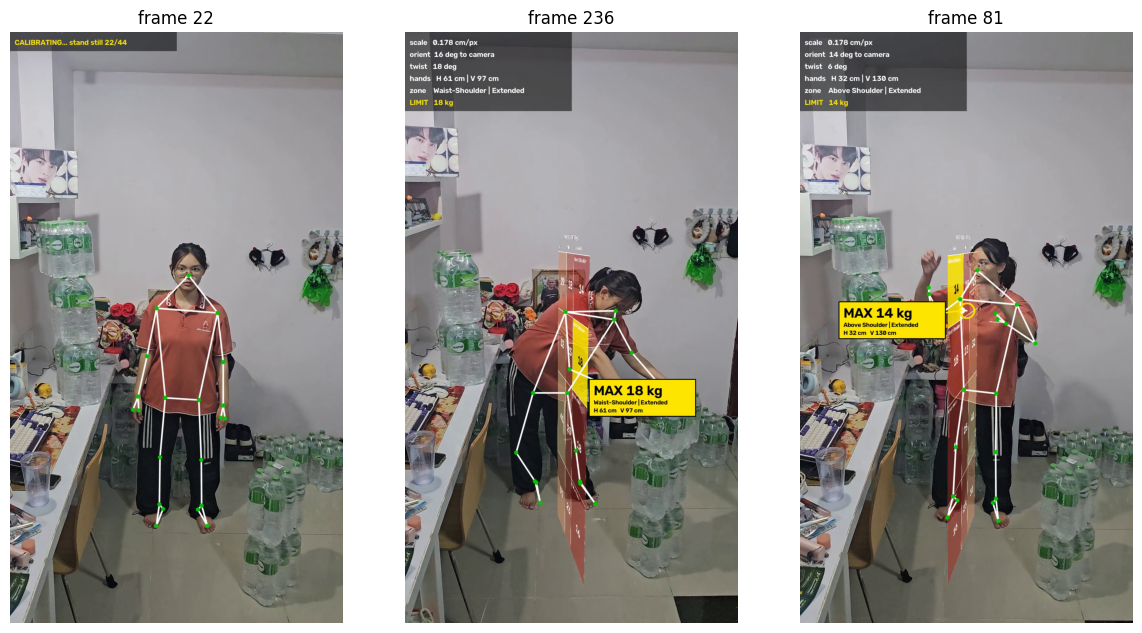

In [27]:
# ภาพนิ่ง 3 จังหวะ: ระหว่าง calibrate · มือยื่นไกลที่สุด · น้ำหนักที่ยอมรับได้ต่ำที่สุด
import pandas as pd
from pathlib import Path

if 'results' not in globals() or 'results' not in locals():
    csv_path = OUTPUT_DIR / f"{stem}_weightlimit.csv"
    if csv_path.exists():
        results = pd.read_csv(csv_path)
    else:
        raise NameError("ไม่พบตัวแปร 'results' และไม่มีไฟล์ CSV ผลลัพธ์ กรุณารันรันเซลล์รหัส '1044b35d' ก่อนหน้าใหม่อีกครั้งครับ")

valid = results.dropna(subset=["limit_kg"])
frame_ids = [CALIB_FRAMES // 2,
             int(valid.loc[valid["H_cm"].idxmax(), "frame_number"]),
             int(valid.loc[valid["limit_kg"].idxmin(), "frame_number"])]
show_images([read_frame(FINAL_OUT, f) for f in frame_ids], [f"frame {f}" for f in frame_ids])

---
## ขั้นที่ 10 · สรุปผล

### 10.1 เส้นเวลา
เส้นประแนวนอน = ขอบของตาราง (เข่า/เอว/ไหล่ · 7″/12″ · 45°) · แถบสีเทา = ช่วง calibrate

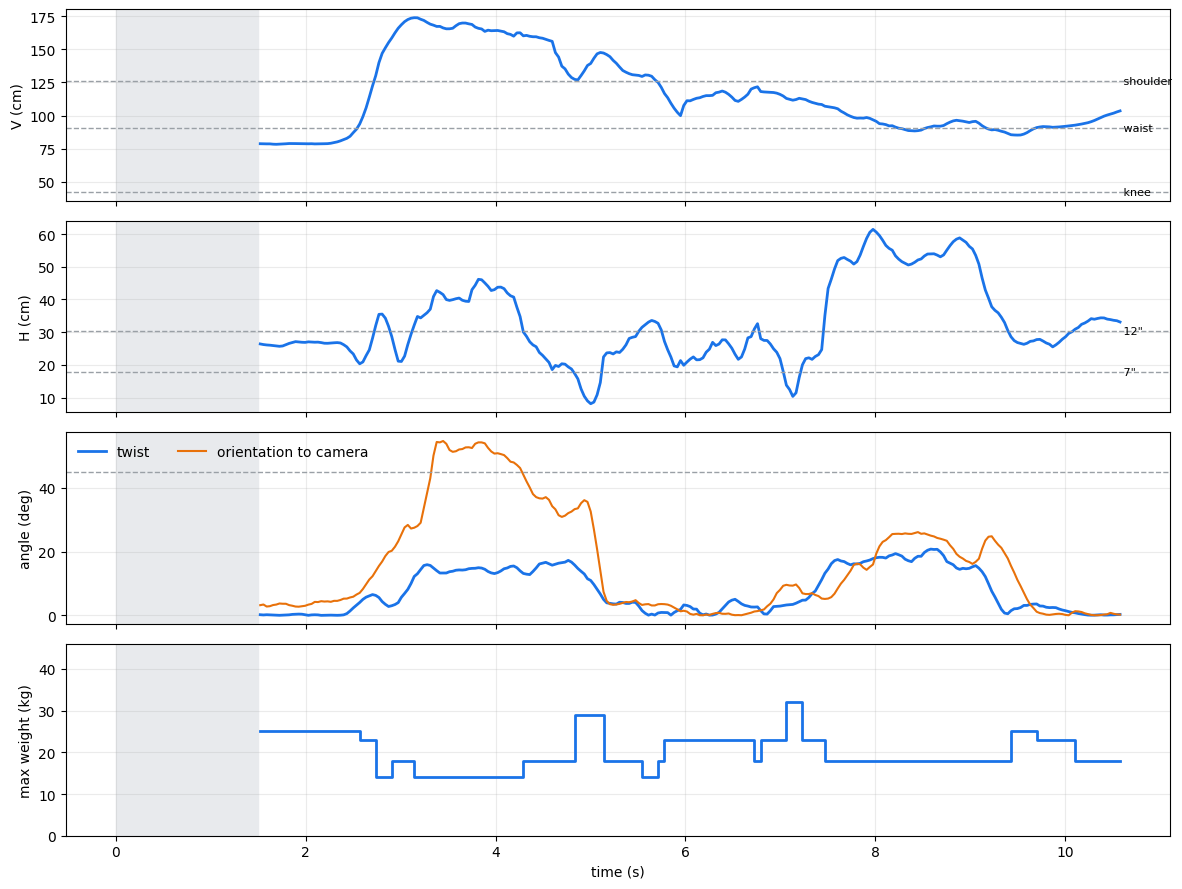

In [28]:
t = results["time_s"]
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
blue, grey = "#1a73e8", "#9aa0a6"

axes[0].plot(t, results["V_cm"], color=blue, lw=2)
for name in ["knee", "waist", "shoulder"]:
    axes[0].axhline(CALIB_RUN[name + "_cm"], color=grey, ls="--", lw=1)
    axes[0].text(t.iloc[-1], CALIB_RUN[name + "_cm"], " " + name, va="center", fontsize=8)
axes[0].set_ylabel("V (cm)")

axes[1].plot(t, results["H_cm"], color=blue, lw=2)
for cm, name in zip(REACH_LIMITS_CM, ['7"', '12"']):
    axes[1].axhline(cm, color=grey, ls="--", lw=1)
    axes[1].text(t.iloc[-1], cm, " " + name, va="center", fontsize=8)
axes[1].set_ylabel("H (cm)")

axes[2].plot(t, results["twist_deg"], color=blue, lw=2, label="twist")
axes[2].plot(t, results["orientation_deg"], color="#e8710a", lw=1.5, label="orientation to camera")
axes[2].axhline(TWIST_WARN_DEG, color=grey, ls="--", lw=1)
axes[2].set_ylabel("angle (deg)")
axes[2].legend(frameon=False, loc="upper left", ncol=2)

axes[3].step(t, results["limit_kg"], where="post", color=blue, lw=2)
axes[3].set_ylim(0, 46)
axes[3].set_ylabel("max weight (kg)")
axes[3].set_xlabel("time (s)")

for ax in axes:
    ax.axvspan(0, CALIB_SECONDS, color="#e8eaed", zorder=0)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 10.2 เวลาที่มืออยู่ในแต่ละช่องของตาราง
ช่องที่มีเวลามากและน้ำหนักต่ำ คือจุดที่ควรปรับสถานีงาน (เช่น ยกของขึ้นจากพื้นมาไว้ระดับเข่า–เอว)

In [29]:
seconds = valid.groupby(["zone", "reach_class"]).size() / FPS
table = seconds.unstack("reach_class").reindex(index=ROW_NAMES, columns=COL_NAMES).fillna(0).round(2)
print("เวลาที่กึ่งกลางมืออยู่ในแต่ละช่อง (วินาที)")
display(table)
worst = valid.loc[valid["limit_kg"].idxmin()]
print(f"น้ำหนักสูงสุดที่ยอมรับได้ ต่ำที่สุดตลอดคลิป = {worst['limit_kg']:.0f} kg (frame {worst['frame_number']:.0f})")

เวลาที่กึ่งกลางมืออยู่ในแต่ละช่อง (วินาที)


reach_class,Near,Mild,Extended
zone,,,
Above Shoulder,0.30,1.18,1.49
Waist-Shoulder,0.17,2.03,2.06
Knee-Waist,0.00,1.32,0.54
Below Knee,0.00,0.00,0.00


น้ำหนักสูงสุดที่ยอมรับได้ ต่ำที่สุดตลอดคลิป = 14 kg (frame 81)


### 10.3 (ไม่บังคับ) เทียบกับรหัสในชื่อไฟล์
ชื่อไฟล์ตามโปรโตคอลบอกเงื่อนไขที่ตั้งใจถ่าย เช่น `G02_S01_WS-KW_RN_T0_PS_01` = ยกจากโซน WS ไป KW · เอื้อม RN · ไม่บิดตัว T0

In [30]:
ZONE_CODE = {"AS": "Above Shoulder", "WS": "Waist-Shoulder", "KW": "Knee-Waist", "BK": "Below Knee"}
found = re.search(r"_([A-Z]{2})-([A-Z]{2})_(R[NMF])_(T[01])_", stem)
if found:
    origin, dest, reach_code, twist_code = found.groups()
    print(f"จากชื่อไฟล์ : {ZONE_CODE.get(origin)} → {ZONE_CODE.get(dest)} · {reach_code} · {twist_code}")
    print("ระบบพบโซน (วินาที):", (valid["zone"].value_counts() / FPS).round(2).to_dict())
    print(f"มุมบิดตัวสูงสุด = {results['twist_deg'].max():.0f}° (เกณฑ์ {TWIST_WARN_DEG:.0f}°)")
else:
    print("ชื่อไฟล์ไม่ตรงรูปแบบโปรโตคอล")

จากชื่อไฟล์ : Above Shoulder → Waist-Shoulder · RF · T1
ระบบพบโซน (วินาที): {'Waist-Shoulder': 4.26, 'Above Shoulder': 2.97, 'Knee-Waist': 1.86}
มุมบิดตัวสูงสุด = 21° (เกณฑ์ 45°)


---
## 🧭 สรุป

| ขั้น | ฟังก์ชันหลัก | สิ่งที่ได้ |
|---|---|---|
| ① | `open_video()` · `cap.read()` | เฟรมภาพ (BGR) |
| ② | `extract_keypoints()` | 33 จุดในภาพ + โครงร่าง 3 มิติ |
| ③ | `PoseSmoother.update()` | จุดที่นิ่งขึ้น (Kalman + moving average) |
| ④ | `draw_skeleton()` | โครงกระดูกบนภาพ |
| ⑤ | `calibrate()` · `solve_camera_pose()` · `to_camera_3d()` · `body_frame()` | cm/px · พิกัด 3 มิติ (ซม.) · กรอบร่างกาย O/up/side/front |
| ⑥ | `orientation_angle()` | มุมหันเทียบกล้อง |
| ⑦ | `twist_from_baseline()` | มุมบิดตัว |
| ⑧ | `measure_hands()` · `draw_weight_table()` · `draw_hand_label()` | H, V แบบ NIOSH · ตาราง 3×4 (perspective) · น้ำหนักสูงสุด |
| ⑨ | `run_pipeline()` · `cv2.VideoWriter` | วิดีโอผลลัพธ์ + CSV |

> ⚠️ **ข้อจำกัด:** ความลึกมาจากโครงร่าง 3 มิติที่ MediaPipe ประมาณจากกล้องตัวเดียว และ FOV ของกล้องเป็นค่าสมมติ — ค่า H ขณะยืนนิ่งมือห้อยอาจได้ราว 20 ซม. ซึ่งสูงกว่าความจริง
> ควรตรวจกับการวัดจริง (เช่น วางกล่องที่ระยะ 7″/12″ แล้วถ่าย) ก่อนนำไปใช้ประเมินความเสี่ยง
> ตาราง 3×4 นี้ใช้ H แบบ NIOSH (จากกึ่งกลางข้อเท้า) — ถ้าเอกสารต้นทางของตารางวัดจากหน้าลำตัว ต้องปรับเกณฑ์คอลัมน์

## 🔬 กิจกรรมทดลอง

| # | สิ่งที่ปรับ (👉 MODIFY) | สิ่งที่สังเกต | ผลที่ได้ |
|---|---|---|---|
| 1 | `SUBJECT_HEIGHT_CM` ±10 ซม. | H, V และช่องในตารางเปลี่ยนไปเท่าไร | |
| 2 | `CALIB_SECONDS` = 0.5, 1.5, 3 | สเกลนิ่งขึ้นหรือเพี้ยนเมื่อใด | |
| 3 | `WORLD_WINDOW` = 1, 5, 15 | ตาราง/มุมบิดกระพริบหรือตอบสนองช้าลงแค่ไหน | |
| 4 | ใช้คลิป T1 (บิดตัว) | twist สูงสุดเกิน 45° หรือไม่ · เกิดตอนไหน | |
| 5 | `WAIST_FRACTION` = 0.2, 0.3, 0.4 | เวลาที่มืออยู่แถว Knee–Waist เปลี่ยนเท่าไร | |
| 6 | `CAMERA_FOV_DEG` = 55, 70, 85 | ตารางดูเอียงต่างกันอย่างไร · ระยะกล้องจาก solvePnP เทียบกับ cm/px | |

## 🧠 คำถามชวนคิด
- **A.** ทำไม NIOSH จึงวัด H จาก **กึ่งกลางข้อเท้า** แทนที่จะวัดจากสะโพก (ลองนึกถึงตอนย่อตัวหยิบของจากพื้น)
- **B.** ทำไมต้องใช้ระดับพื้นและแนวดิ่งจากช่วงยืนนิ่ง แทนที่จะวัดใหม่ทุกเฟรม
- **C.** ถ้าจะรวม notebook นี้กับ `Workshop_LiftCounter_LSTM_Colab.ipynb` ควรรายงานน้ำหนักสูงสุด **ณ เฟรมใด** ของการยกหนึ่งครั้ง

A. ตอบ:
1. เป็นจุดหมุนและจุดรับน้ำหนักหลักของร่างกายที่สมดุลกับพื้น: ในทางชีวกลศาสตร์ (Biomechanics) แรงบิดที่เกิดขึ้นกับกระดูกสันหลังส่วนล่าง (L5/S1) และแรงกดที่ส่งลงสู่พื้นจะสมดุลกันที่ฐานราก ซึ่งก็คือบริเวณข้อเท้าและฝ่าเท้า

2. คำนึงถึงสรีระและการย่อตัว: หากเราใช้สะโพกเป็นจุดอ้างอิง เมื่อผู้ยกย่อตัวลง (Squat) สะโพกจะยื่นไปข้างหลัง ทำให้ระยะห่างจากสะโพกถึงวัตถุดูเหมือนกว้างขึ้น ทั้งที่ในความเป็นจริงจุดฐานที่เท้าไม่ได้ขยับ การใช้กึ่งกลางข้อเท้าซึ่งอยู่ติดกับพื้นถาวรตลอดการยก จึงสะท้อนถึงระยะการเอื้อมที่แท้จริงและมีความเสถียรมากกว่าในการประเมินความเสี่ยงต่อการเสียสมดุลและการล้ม

B. ตอบ:
1. เพื่อป้องกันปัญหาระดับพื้นขยับและตัวสั่น (Jitter/Drift): ระหว่างการยกจริง ข้อเท้าและเท้าจะมีการบดบัง ขยับตัว หรือสั่นไหว หากเราคำนวณหาระดับพื้นและแนวดิ่งใหม่ในทุกเฟรม ค่าระดับพื้น (Floor Level) จะแกว่งขึ้นลงตามท่วงท่า ส่งผลให้ค่าความสูงมือ (V) เพี้ยนตามไปด้วย

2. ความเสถียรของสมการ: การกำหนดระดับพื้นคงที่จากช่วงยืนนิ่ง (Calibration Phase) ทำให้เรามีจุดอ้างอิงเชิงกลศาสตร์ (Reference Plane) ที่นิ่งและแม่นยำตลอดทั้งคลิป ช่วยลดความผิดพลาดของการวัดพิกัด 3 มิติเชิงเรขาคณิตได้ดีที่สุด

C. ตอบ: ควรรันรายงาน ณ "เฟรมที่มือยื่นห่างจากตัวมากที่สุด" (Max H) หรือ "เฟรมที่มีค่าเกณฑ์น้ำหนักปลอดภัยต่ำที่สุด"